Nama: Lutfi Z<br>
NIM: 12231948<br>
Mata Kuliah: Big Data.

UTS Big Data: <br>
Soal A:<br>
1. Bagaimana penggabungan dataset-dataset di atas dan mengetahui jumlah seluruh baris datanya?<br>
2. Bagaimana proses removing outliers pada kolom harga? <br>
3. Bagaimana checking missing value data dan berapa jumlah data missing valuenya?<br>
4. Bagaimana checking duplikasi dan melakukan deduplikassi dataset tersebut?<br>
Soal B:<br>
Bagaimana melakukan visualisasi data dari soal A dengan Grafik Line Chart untuk penjualan produk susu bubuk 195g?<br>


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

df_mgl = pd.read_csv('/content/drive/MyDrive/Big_Data/transaksi_ritel_mgl.csv')
df_yk = pd.read_csv('/content/drive/MyDrive/Big_Data/transaksi_ritel_yk.csv')

1. Menggabungkan kedua dataset:

In [18]:
df_gabung = pd.concat([df_mgl, df_yk], ignore_index=True)
df_gabung.columns = df_gabung.columns.str.strip()
print(df_gabung.columns)

Index(['tanggal', 'kode', 'nama', 'jumlah', 'harga', 'area'], dtype='object')


1. Mencari jumlah seluruh baris data:

In [19]:
total_baris = df_gabung.shape[0]
print(f"Jumlah total baris setelah digabungkan adalah {total_baris}")

Jumlah total baris setelah digabungkan adalah 23849


2. Proses Removing outliers kolom harga:

In [20]:
# Menghitung IQR untuk kolom harga (mengabaikan NaN sementara untuk kalkulasi)
Q1 = df_gabung['harga'].quantile(0.25)
Q3 = df_gabung['harga'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Memfilter data (menyimpan data yang berada di dalam batas IQR ATAU data yang memang NaN agar tidak hilang sebelum dicek missing value-nya)
df_clean_outlier = df_gabung[(df_gabung['harga'] >= batas_bawah) & (df_gabung['harga'] <= batas_atas) | (df_gabung['harga'].isna())]

print(f"Jumlah baris setelah outliers dihapus: {df_clean_outlier.shape[0]} baris")

Jumlah baris setelah outliers dihapus: 21455 baris


3. cek missing value data

In [21]:
# Checking missing value per kolom
missing_per_kolom = df_clean_outlier.isnull().sum()
total_missing = df_clean_outlier.isnull().sum().sum()

print("Jumlah missing value per kolom:")
print(missing_per_kolom)
print(f"\nTotal seluruh data missing value: {total_missing}")

# Opsional: Jika ingin mengisi atau menghapus missing value untuk keperluan analisis selanjutnya
# Misalnya, menghapus baris yang missing value:
df_no_missing = df_clean_outlier.dropna().copy()

Jumlah missing value per kolom:
tanggal     36
kode        33
nama       108
jumlah     103
harga      106
area         0
dtype: int64

Total seluruh data missing value: 386


4. Checking Duplikasi

In [22]:
# Menghitung jumlah data duplikat
jumlah_duplikat = df_no_missing.duplicated().sum()
print(f"Jumlah data duplikat yang ditemukan: {jumlah_duplikat}")

# Melakukan deduplikasi (menghapus data duplikat)
df_final = df_no_missing.drop_duplicates()
print(f"Jumlah baris akhir setelah deduplikasi: {df_final.shape[0]} baris")

Jumlah data duplikat yang ditemukan: 6842
Jumlah baris akhir setelah deduplikasi: 14500 baris


In [23]:
import pandas as pd

# 1. Load dataset
df_mgl = pd.read_csv('/content/drive/MyDrive/Big_Data/transaksi_ritel_mgl.csv')
df_yk = pd.read_csv('/content/drive/MyDrive/Big_Data/transaksi_ritel_yk.csv')

# 2. Gabungkan data
df_gabung = pd.concat([df_mgl, df_yk], ignore_index=True)

# 3. Membersihkan dari spasi
df_gabung.columns = df_gabung.columns.str.strip()
print(df_gabung.columns)

Index(['tanggal', 'kode', 'nama', 'jumlah', 'harga', 'area'], dtype='object')


In [24]:
import pandas as pd

# 1. Load & Gabung Data
df_mgl = pd.read_csv('/content/drive/MyDrive/Big_Data/transaksi_ritel_mgl.csv')
df_yk = pd.read_csv('/content/drive/MyDrive/Big_Data/transaksi_ritel_yk.csv')
df_gabung = pd.concat([df_mgl, df_yk], ignore_index=True)

# 2. Bersihkan nama kolom dari spasi ghaib
df_gabung.columns = df_gabung.columns.str.strip()

# 3. Hitung IQR untuk Outliers
Q1 = df_gabung['harga'].quantile(0.25)
Q3 = df_gabung['harga'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Kondisi A: Harga normal (dalam batas IQR)
kondisi_normal = (df_gabung['harga'] >= batas_bawah) & (df_gabung['harga'] <= batas_atas)
# Kondisi B: Harga yang kosong/NaN
kondisi_nan = (df_gabung['harga'].isna())

df_clean_outlier = df_gabung[kondisi_normal | kondisi_nan]

print(f"Jumlah baris setelah outliers difilter: {df_clean_outlier.shape[0]} baris")

Jumlah baris setelah outliers difilter: 21455 baris


**B. Visualisasi Data**

Produk paling laku untuk visualisasi NIM 12231948: 'Susu Bubuk 195g' (Terjual: 15450 item)


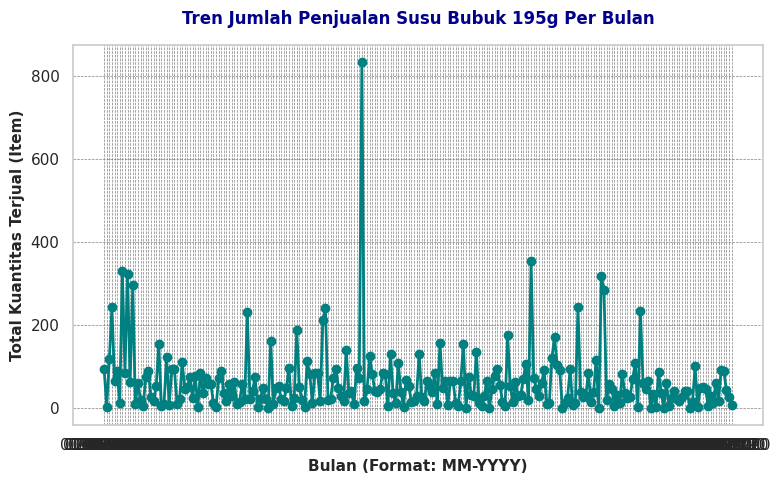

In [31]:
# Mencari produk yang paling laku secara akumulatif untuk divisualisasikan trennya
produk_terlaris = df_gabung.groupby('nama')['jumlah'].sum().idxmax()
total_terjual = df_gabung.groupby('nama')['jumlah'].sum().max()
print(f"Produk paling laku untuk visualisasi NIM 12231948: '{produk_terlaris}' (Terjual: {int(total_terjual)} item)")

# Memfilter data hanya untuk produk terlaris tersebut
df_produk_tren = df_gabung[df_gabung['nama'] == produk_terlaris]

# Mengelompokkan total kuantitas produk terlaris berdasarkan urutan bulan transaksi
tren_bulanan = df_produk_tren.groupby('tanggal')['jumlah'].sum().sort_index()

# Membuat grafik Line Chart
plt.figure(figsize=(8, 5))
plt.plot(tren_bulanan.index, tren_bulanan.values, marker='o', color='teal', linewidth=2, linestyle='-')

# Mengatur komponen grafik (Judul, Label, Grid)
plt.title(f"Tren Jumlah Penjualan {produk_terlaris} Per Bulan", pad=15, fontsize=12, color="darkblue", weight="bold")
plt.xlabel("Bulan (Format: MM-YYYY)", fontsize=11, weight="bold")
plt.ylabel("Total Kuantitas Terjual (Item)", fontsize=11, weight="bold")
plt.grid(color="gray", linestyle="--", linewidth=0.5)

# Menampilkan Grafik
plt.tight_layout()
plt.show()